<a href="https://colab.research.google.com/github/Sneha-code01/ML/blob/main/batterypredict_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# current inida = 0.71, renewable = 0.05, 2035 = 0.35 _CAE
# manufacture = 65kwh electricity required and used 20 for 100%recycle credit
import pandas as pd
from itertools import product

chemistries = [
    'LFP','LTO','LMO','LCO','NCA',
    'NMC111','NMC442','NMC532','NMC622',
    'NMC811',

]

scenarios = [
    'Current_India_Grid',
    'Renewable_India',
    'India_2035'
]

recycling_rates = [0,20,30,40,50,60,70,80,90,100]

energy_density = {
    'LFP':140,
    'LTO':80,
    'LMO':150,
    'LCO':190,
    'NCA':260,
    'NMC111':230,
    'NMC442':210,
    'NMC532':220,
    'NMC622':260,
    'NMC811':280,
}
cycle_life = {
'LFP':4000,
'LTO':10000,
'LMO':1000,
'LCO':800,
'NCA':1500,
'NMC111':2000,
'NMC442':2200,
'NMC532':2500,
'NMC622':3000,
'NMC811':3500,
}
#co2 equivalent calculation
material_emission = {
    'LFP':30,
    'LTO':33,
    'LMO':34,
    'LCO':48,
    'NCA':52,
    'NMC111':43,
    'NMC442':45,
    'NMC532':47,
    'NMC622':50,
    'NMC811':54,
}

cell_production = {
    'LFP':13,
    'LTO':14,
    'LMO':14,
    'LCO':15,
    'NCA':17,
    'NMC111':15,
    'NMC442':15,
    'NMC532':16,
    'NMC622':17,
    'NMC811':18,
}

grid_factor = {
    'Current_India_Grid':0.71,
    'Renewable_India':0.05,
    'India_2035':0.35
}

data = list(product(
    chemistries,
    scenarios,
    recycling_rates
))

df = pd.DataFrame(
    data,
    columns=[
        'Chemistry',
        'Scenario',
        'Recycling_Rate'
    ]
)

df['Energy_Density_kWh'] = (
    df['Chemistry']
    .map(energy_density)
)
df['Cycle_Life'] = (
    df['Chemistry']
    .map(cycle_life)
)

df['Material_Emission'] = (
    df['Chemistry']
    .map(material_emission)
)

df['Cell_Production_Emission'] = (
    df['Chemistry']
    .map(cell_production)
)

df['Base_Emission'] = (
    df['Material_Emission']
    +
    df['Cell_Production_Emission']
)

df['Grid_Factor'] = (
    df['Scenario']
    .map(grid_factor)
)

# Manufacturing electricity demand
manufacturing_energy = 65

df['Manufacturing_Emission'] = (
    manufacturing_energy
    *
    df['Grid_Factor']
)

# Recycling credit
df['Recycling_Credit'] = (
    20
    *
    df['Recycling_Rate']
    /100
)
#unit co2-eq-gwp100
# Final target column of co2 equivalent
df['CO2-eq'] = (
    df['Base_Emission']
    +
    df['Manufacturing_Emission']
    -
    df['Recycling_Credit']
)


# Acidification factors for electricity scenarios
#unit is kg_so2_eq
acid_grid_factor = {
    'Current_India_Grid':0.0045,
    'India_2035':0.0020,
    'Renewable_India':0.0005
}

# Base acidification values (kg SO2-eq/kWh battery)
base_acidification = {
    'LFP':0.16,
    'LTO':0.18,
    'LMO':0.25,
    'LCO':0.42,
    'NCA':0.48,
    'NMC111':0.28,
    'NMC442':0.31,
    'NMC532':0.34,
    'NMC622':0.40,
    'NMC811':0.43,
}
# Chemistry-specific recycling credits for acidification
acid_recycling_credit = {
    'LFP': 0.04,
    'LTO': 0.04,
    'LMO': 0.05,
    'LCO': 0.10,
    'NCA': 0.12,
    'NMC111': 0.08,
    'NMC442': 0.09,
    'NMC532': 0.10,
    'NMC622': 0.11,
    'NMC811': 0.12,
}
# Adding base acidification column
df['Base_Acidification'] = df['Chemistry'].map(base_acidification)

df['Acid_Grid_Factor'] = df['Scenario'].map(acid_grid_factor)

manufacturing_energy = 65

df['Manufacturing_Acidification'] = (
    manufacturing_energy * df['Acid_Grid_Factor']
)

df['Acidification_Credit'] = (
    df['Chemistry'].map(acid_recycling_credit)
    * df['Recycling_Rate']
    / 100
)

df['Acidification-eq'] = (
    df['Base_Acidification']
    + df['Manufacturing_Acidification']
    - df['Acidification_Credit']
)
#Human Toxicity Potential (HTP) Nickel mining, Cobalt mining, Lithium production, Graphite processing
#taken from the research papers and greet it sthe value due to the material it self
base_htp = {
    'LFP':8,
    'LTO':9,
    'LMO':11,
    'LCO':28,
    'NCA':32,
    'NMC111':22,
    'NMC442':24,
    'NMC532':26,
    'NMC622':29,
    'NMC811':34
}
#kg 1,4-DCB-eq/kWh is unit of htp
#because electricity contributes much less to HTP than material extraction.(65*elec source htp contri)
htp_grid_factor = {
    'Current_India_Grid':0.035,
    'India_2035':0.020,
    'Renewable_India':0.008
}
#High Ni/Co chemistries gain more from recycling. ie the htp is very less in such cases
recycling_credit_htp = {
    'LFP':4,
    'LTO':4,
    'LMO':5,
    'LCO':12,
    'NCA':14,
    'NMC111':10,
    'NMC442':11,
    'NMC532':12,
    'NMC622':13,
    'NMC811':14
}
#htp column addition
df['Base_HTP'] = df['Chemistry'].map(base_htp)

df['HTP_Grid_Factor'] = df['Scenario'].map(htp_grid_factor)

df['Manufacturing_HTP'] = (
    65 * df['HTP_Grid_Factor']
)

df['HTP_Recycling_Credit'] = (
    df['Chemistry'].map(recycling_credit_htp)
    * df['Recycling_Rate']
    / 100
)

df['Human_Toxicity'] = (
    df['Base_HTP']
    + df['Manufacturing_HTP']
    - df['HTP_Recycling_Credit']
)
#papers by Majeau-Bettez, Ellingsen, and Ciez & Whitacre and data from niti ayoag and greet
print(df[['Chemistry',
        'Scenario',
        'Recycling_Rate',
        'CO2-eq',
        'Energy_Density_kWh',
          'Cycle_Life',
        'Acidification-eq',
          'Human_Toxicity']])

df.to_csv(
    'battery_dataset.csv',
    index=False
)


    Chemistry            Scenario  Recycling_Rate  CO2-eq  Energy_Density_kWh  \
0         LFP  Current_India_Grid               0   89.15                 140   
1         LFP  Current_India_Grid              20   85.15                 140   
2         LFP  Current_India_Grid              30   83.15                 140   
3         LFP  Current_India_Grid              40   81.15                 140   
4         LFP  Current_India_Grid              50   79.15                 140   
..        ...                 ...             ...     ...                 ...   
295    NMC811          India_2035              60   82.75                 280   
296    NMC811          India_2035              70   80.75                 280   
297    NMC811          India_2035              80   78.75                 280   
298    NMC811          India_2035              90   76.75                 280   
299    NMC811          India_2035             100   74.75                 280   

     Cycle_Life  Acidificat

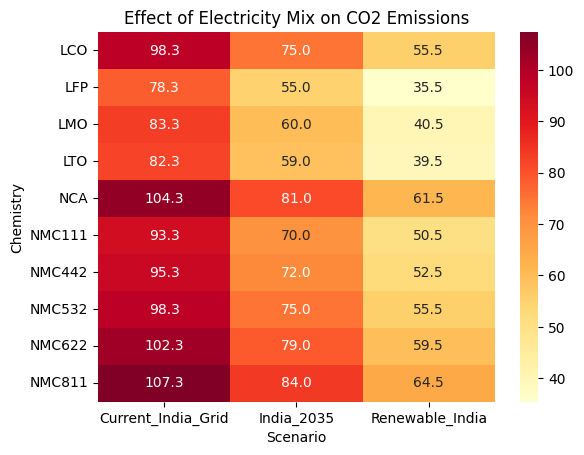

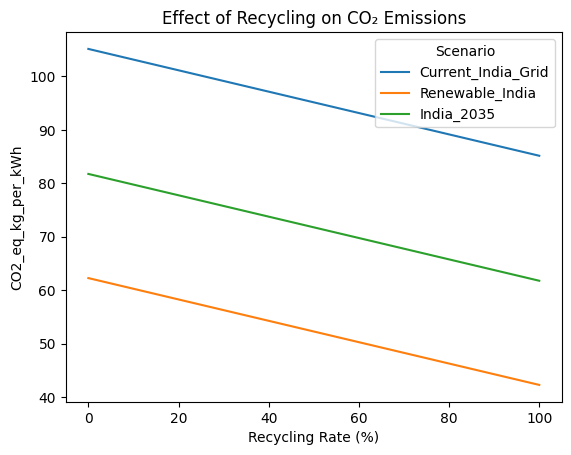

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
pivot = df.pivot_table(
    values='CO2-eq',
    index='Chemistry',
    columns='Scenario',
    aggfunc='mean'
)

sns.heatmap(
    pivot,
    annot=True,
    cmap='YlOrRd',
    fmt='.1f'
)

plt.title('Effect of Electricity Mix on CO2 Emissions')
plt.show()
plt.figure()
sns.lineplot(
    data=df,
    x='Recycling_Rate',
    y='CO2-eq',
    hue='Scenario',
    errorbar=None
)

plt.xlabel('Recycling Rate (%)')
plt.ylabel('CO2_eq_kg_per_kWh')
plt.title('Effect of Recycling on CO₂ Emissions')
plt.show()


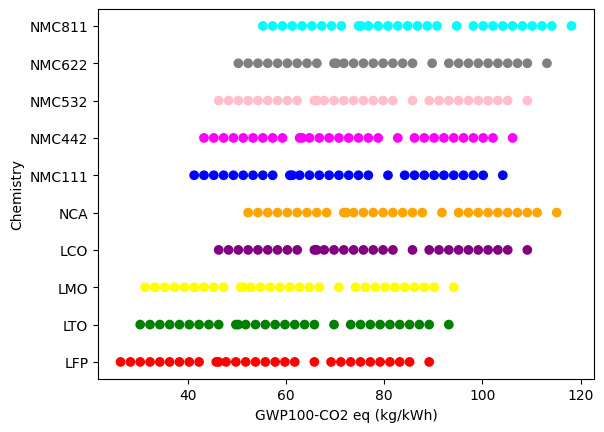

In [4]:
import matplotlib.pyplot as plt
color_map = {
    'LFP':'red',
    'LTO':'green',
    'LMO':'yellow',
    'LCO':'purple',
    'NCA':'orange',
    'NMC111':'blue',
     'NMC442':'magenta',
    'NMC532':'pink',
    'NMC622':'grey',
    'NMC811':'cyan',
    'NMC442':'magenta'
}

plt.scatter(
    df['CO2-eq'],
    df['Chemistry'],
    c=df['Chemistry'].map(color_map)
)

plt.xlabel('GWP100-CO2 eq (kg/kWh)')
plt.ylabel('Chemistry')
plt.show()

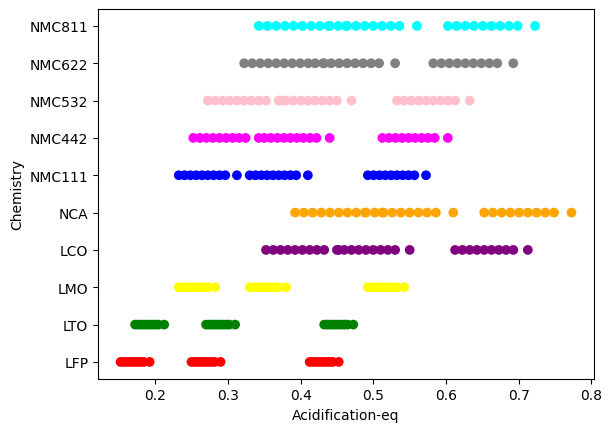

In [5]:
import matplotlib.pyplot as plt
color_map = {
    'LFP':'red',
    'LTO':'green',
    'LMO':'yellow',
    'LCO':'purple',
    'NCA':'orange',
    'NMC111':'blue',
    'NMC442':'magenta',
    'NMC532':'pink',
    'NMC622':'grey',
    'NMC811':'cyan',

}
plt.scatter(
    df['Acidification-eq'],
    df['Chemistry'],
    c=df['Chemistry'].map(color_map)
)

plt.xlabel('Acidification-eq')
plt.ylabel('Chemistry')
plt.show()

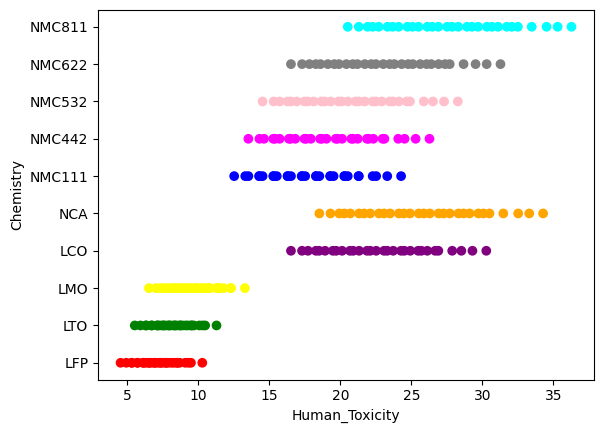

In [6]:
import matplotlib.pyplot as plt
color_map = {
    'LFP':'red',
    'LTO':'green',
    'LMO':'yellow',
    'LCO':'purple',
    'NCA':'orange',
    'NMC111':'blue',
    'NMC442':'magenta',
    'NMC532':'pink',
    'NMC622':'grey',
    'NMC811':'cyan',

}
plt.scatter(
    df['Human_Toxicity'],
    df['Chemistry'],
    c=df['Chemistry'].map(color_map)
)

plt.xlabel('Human_Toxicity')
plt.ylabel('Chemistry')
plt.show()

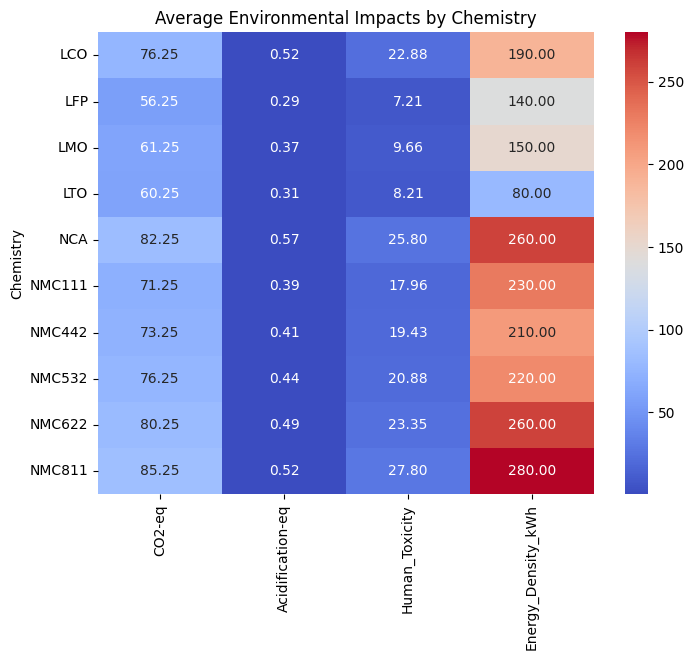

In [7]:
#plotting co2,acidification and htp graph together
import seaborn as sns
import matplotlib.pyplot as plt

avg_df = df.groupby('Chemistry')[
    [
        'CO2-eq',
        'Acidification-eq',
        'Human_Toxicity',
        'Energy_Density_kWh',
    ]
].mean()

plt.figure(figsize=(8,6))

sns.heatmap(
    avg_df,
    annot=True,
    cmap = 'coolwarm',
    fmt='.2f'
)

plt.title('Average Environmental Impacts by Chemistry')
plt.show()

In [8]:
#mathematical analysis from the data
df.describe()

,Recycling_Rate,Energy_Density_kWh,Cycle_Life,Material_Emission,Cell_Production_Emission,Base_Emission,Grid_Factor,Manufacturing_Emission,Recycling_Credit,CO2-eq,Base_Acidification,Acid_Grid_Factor,Manufacturing_Acidification,Acidification_Credit,Acidification-eq,Base_HTP,HTP_Grid_Factor,Manufacturing_HTP,HTP_Recycling_Credit,Human_Toxicity
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.00000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,54.000000,202.000000,3050.000000,43.600000,15.400000,59.00000,0.370000,24.050000,10.800000,72.250000,0.325000,0.002333,0.151667,0.045900,0.430767,22.300000,0.021000,1.365000,5.346000,18.319000
std,30.448158,59.731842,2518.261066,8.028378,1.499164,9.43912,0.270266,17.567262,6.089632,20.851602,0.103153,0.001653,0.107424,0.031793,0.141459,9.148167,0.011064,0.719148,3.840083,7.823693
min,0.000000,80.000000,800.000000,30.000000,13.000000,43.00000,0.050000,3.250000,0.000000,26.250000,0.160000,0.000500,0.032500,0.000000,0.152500,8.000000,0.008000,0.520000,0.000000,4.520000
25%,30.000000,150.000000,1500.000000,34.000000,14.000000,48.00000,0.050000,3.250000,6.000000,56.250000,0.250000,0.000500,0.032500,0.021500,0.324000,11.000000,0.008000,0.520000,2.400000,10.275000
50%,55.000000,215.000000,2350.000000,46.000000,15.000000,61.50000,0.350000,22.750000,11.000000,71.750000,0.325000,0.002000,0.130000,0.040000,0.429250,25.000000,0.020000,1.300000,4.300000,19.310000
75%,80.000000,260.000000,3500.000000,50.000000,17.000000,67.00000,0.710000,46.150000,16.000000,88.300000,0.420000,0.004500,0.292500,0.070500,0.530000,29.000000,0.035000,2.275000,8.400000,24.158750
max,100.000000,280.000000,10000.000000,54.000000,18.000000,72.00000,0.710000,46.150000,20.000000,118.150000,0.480000,0.004500,0.292500,0.120000,0.772500,34.000000,0.035000,2.275000,14.000000,36.275000


Text(0.5, 0.5, 'GHG')

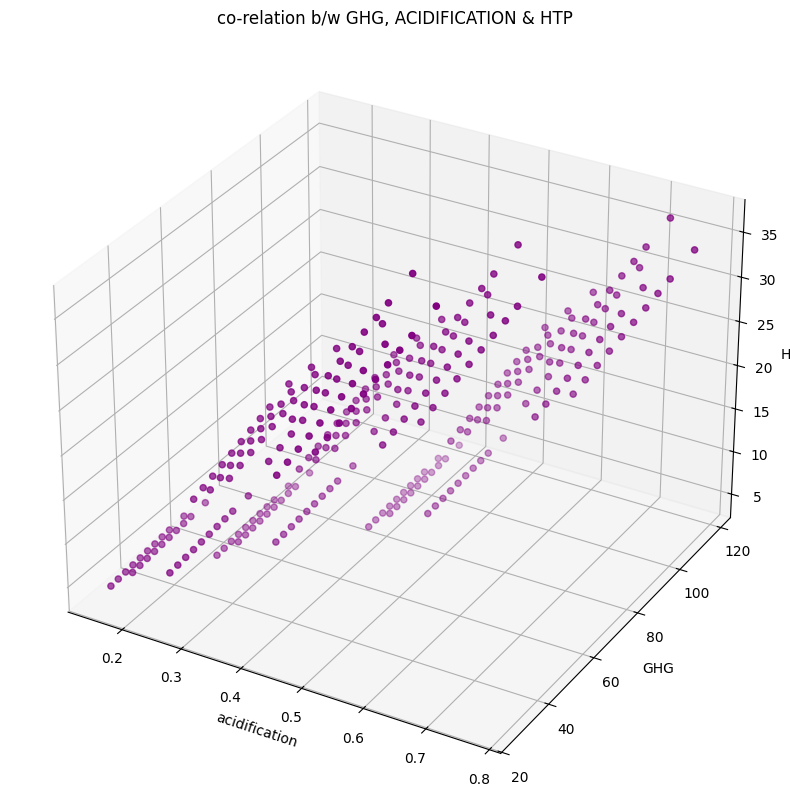

In [9]:
#3d plot to check relation b/w co2 nox/sox and htp
fig = plt.figure(figsize=(16,10))
ax= plt.subplot(projection='3d')
ax.scatter3D(df['Acidification-eq'],df['CO2-eq'],df['Human_Toxicity'],c='purple')
ax.set_title('co-relation b/w GHG, ACIDIFICATION & HTP')
ax.set_zlabel('HTP')
ax.set_xlabel('acidification')
ax.set_ylabel('GHG')

    Chemistry    CO2-eq  Acidification-eq  Human_Toxicity  Energy_Density_kWh  \
0         LFP  0.684440          0.483871        0.181231                 0.3   
1         LFP  0.640914          0.470968        0.156038                 0.3   
2         LFP  0.619151          0.464516        0.143442                 0.3   
3         LFP  0.597388          0.458065        0.130846                 0.3   
4         LFP  0.575626          0.451613        0.118249                 0.3   
..        ...       ...               ...             ...                 ...   
295    NMC811  0.614799          0.541129        0.704771                 1.0   
296    NMC811  0.593036          0.521774        0.660683                 1.0   
297    NMC811  0.571273          0.502419        0.616596                 1.0   
298    NMC811  0.549510          0.483065        0.572508                 1.0   
299    NMC811  0.527748          0.463710        0.528421                 1.0   

     Cycle_norm  
0      0.

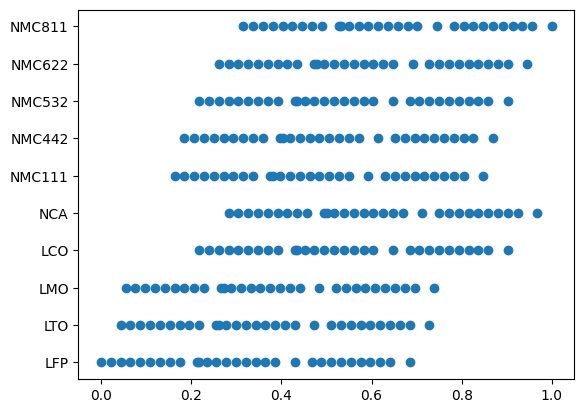

In [10]:
#EDA done to normalize the major colums and bring the value in range of 0-1 and perform better ml training'
from sklearn.preprocessing import MinMaxScaler
import numpy as np
scaler = MinMaxScaler()
cols = [
    'CO2-eq',
    'Acidification-eq',
    'Human_Toxicity',
    'Energy_Density_kWh',
]
df[cols] = scaler.fit_transform(df[cols])
df['Cycle_log'] = np.log10(df['Cycle_Life'])
df[['Cycle_norm']] = scaler.fit_transform(
    df[['Cycle_log']]
)
print(df[[ 'Chemistry','CO2-eq',
    'Acidification-eq',
    'Human_Toxicity','Energy_Density_kWh','Cycle_norm']])
plt.scatter(df['CO2-eq'],df['Chemistry'])

In [11]:
#adding the sustainabilty,performance and cost column
df['sustainability_score'] =1-(df['Acidification-eq']+df['CO2-eq']+df['Human_Toxicity'])/3
#for overall performance cycle and energy density is important
#cost score calculation data used:
#BatPaC (Argonne) → overall pack costs.
#CellEst 3.0 → chemistry-specific cell costs.
#Ciez & Whitacre (2019) → recycling economics.
#Harper et al. (2019) → recovered material value.
battery_cost = {
'LFP':90,
'LTO':180,
'LMO':105,
'LCO':150,
'NCA':135,
'NMC111':120,
'NMC442':118,
'NMC532':115,
'NMC622':125,
'NMC811':130
}
df['Battery_Cost'] = df['Chemistry'].map(battery_cost)
#High Ni/Co chemistries benefit more from recycling because valuable metals are recovered.
cost_credit = {
    'LFP':0.05,
    'LTO':0.03,
    'LMO':0.06,
    'LCO':0.15,
    'NCA':0.18,
    'NMC111':0.10,
    'NMC442':0.12,
    'NMC532':0.14,
    'NMC622':0.16,
    'NMC811':0.20,
}
df['Cost_Credit'] = df['Chemistry'].map(cost_credit)
df['Adjusted_Cost'] = (
    df['Battery_Cost']
    *(1-df['Cost_Credit']*df['Recycling_Rate']/100)
)
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

df['cost_score'] = 1 - scaler.fit_transform(
    df[['Adjusted_Cost']]
).flatten()

df['cost_score'] = np.power(df['cost_score'],0.5)

#performance
df['performance_score']=(
0.85*df['Energy_Density_kWh']
+
0.15*df['Cycle_norm']
)
df['cost_score'] = np.sqrt(df['cost_score'])
safety_score = {
    'LFP'    : 0.95,
    'LTO'    : 0.97,
    'LMO'    : 0.94,
    'LCO'    : 0.85,
    'NCA'    : 0.82,
    'NMC111' : 0.90,
    'NMC442' : 0.88,
    'NMC532' : 0.86,
    'NMC622' : 0.84,
    'NMC811' : 0.80
}

df['safety_score'] = df['Chemistry'].map(safety_score)


print(df[['Chemistry','sustainability_score','performance_score','cost_score','safety_score']].sample(6))

    Chemistry  sustainability_score  performance_score  cost_score  \
249    NMC622              0.381775           0.843497    0.943860   
58        LTO              0.819302           0.150000    0.476213   
213    NMC532              0.292797           0.662670    0.932454   
225    NMC532              0.657063           0.662670    0.942788   
228    NMC532              0.732744           0.662670    0.957679   
271    NMC811              0.083685           0.937652    0.874232   

     safety_score  
249          0.84  
58           0.97  
213          0.86  
225          0.86  
228          0.86  
271          0.80  


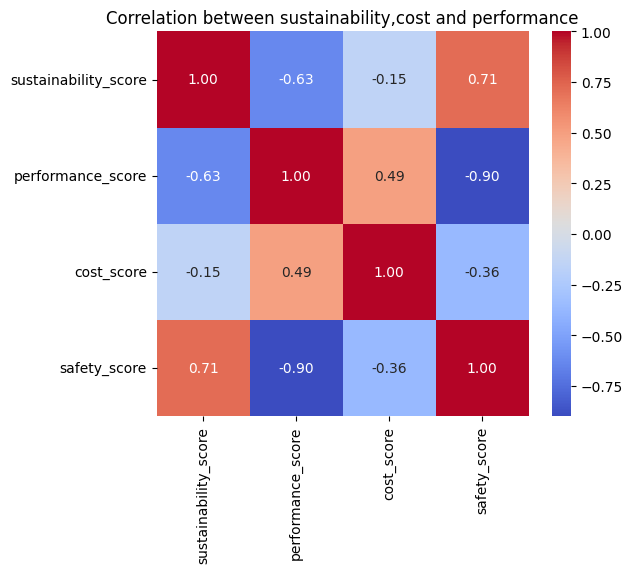

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['sustainability_score','performance_score','cost_score','safety_score'

]

plt.figure(figsize=(6,5))

sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation between sustainability,cost and performance')
plt.show()

In [13]:
#creating the dataset for ml to train and test by giving it random nos input as prirority percentage for sustainability,cost and performance

import numpy as np
import pandas as pd

recommended = []

for i in range(5000):

    weights = np.random.dirichlet(np.ones(4), size=1)[0]

    wsust = weights[0]
    wpref = weights[1]
    wcost = weights[2]
    wsafety = weights[3]

    df['final_score'] = (
        wsust * df['sustainability_score']
        + wpref * df['performance_score']
        + wcost * df['cost_score']
        + wsafety * df['safety_score']
    )

    best = df.loc[df['final_score'].idxmax()]

    recommended.append(
        [
            wsust,
            wpref,
            wcost,
            wsafety,
            best['Chemistry'],

        ]
    )

ml_df = pd.DataFrame(
    recommended,
    columns=[
        'sustainability_priority',
        'performance_priority',
        'cost_priority',
        'safety_priority',
        'Recommended_Chemistry'
    ]
)

print(ml_df)

      sustainability_priority  performance_priority  cost_priority  \
0                    0.174625              0.388760       0.177604   
1                    0.005903              0.604119       0.127321   
2                    0.186214              0.262574       0.117889   
3                    0.730283              0.029970       0.112848   
4                    0.248424              0.531738       0.052204   
...                       ...                   ...            ...   
4995                 0.420898              0.049606       0.379122   
4996                 0.416526              0.267994       0.149920   
4997                 0.086496              0.377147       0.046656   
4998                 0.481622              0.266532       0.031129   
4999                 0.329830              0.130062       0.153244   

      safety_priority Recommended_Chemistry  
0            0.259011                NMC811  
1            0.262657                NMC811  
2            0.433322

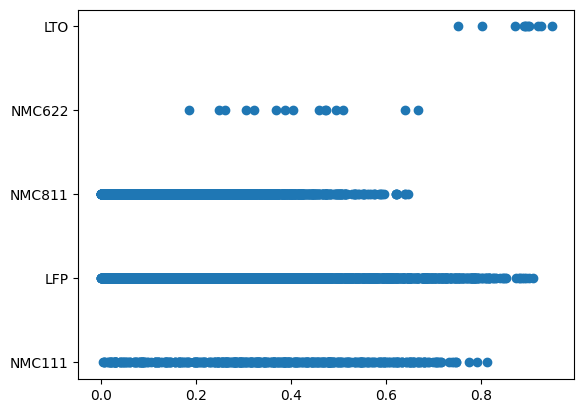

In [ ]:
plt.scatter(ml_df['safety_priority'],ml_df['Recommended_Chemistry'])

In [14]:
print(ml_df['Recommended_Chemistry'].value_counts())

Recommended_Chemistry
LFP       2508
NMC811    1996
NMC111     454
NMC622      36
LTO          6
Name: count, dtype: int64


In [15]:
print(df.groupby('Chemistry')[
[
'sustainability_score',
'performance_score',
'cost_score',
'safety_score'
]
].mean())

           sustainability_score  performance_score  cost_score  safety_score
Chemistry                                                                   
LCO                    0.429539           0.467500    0.815129          0.85
LFP                    0.789041           0.350583    0.994458          0.95
LMO                    0.699599           0.310752    0.954332          0.94
LTO                    0.753283           0.150000    0.379382          0.97
NCA                    0.350674           0.802332    0.884203          0.82
NMC111                 0.568783           0.691917    0.915569          0.90
NMC442                 0.532977           0.612578    0.926211          0.88
NMC532                 0.493544           0.662670    0.939331          0.86
NMC622                 0.423858           0.843497    0.912736          0.84
NMC811                 0.345680           0.937652    0.905980          0.80


In [16]:
X=ml_df.drop('Recommended_Chemistry',axis=1)

y=ml_df['Recommended_Chemistry']
print(y)

0       NMC811
1       NMC811
2       NMC111
3          LFP
4       NMC811
         ...  
4995       LFP
4996       LFP
4997    NMC811
4998       LFP
4999       LFP
Name: Recommended_Chemistry, Length: 5000, dtype: object


In [17]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=10,
    criterion='gini',
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [19]:
y_pred=dt.predict(X_test)
from sklearn.metrics import accuracy_score
print("accuracy of Desicion Tree model:",accuracy_score(y_test,y_pred))

accuracy of Desicion Tree model: 0.934


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf=rf.predict(X_test)

print(
    "Random Forest Accuracy =",
    accuracy_score(y_test,y_pred_rf)
)

Random Forest Accuracy = 0.982


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         LFP       0.99      0.99      0.99       499
         LTO       1.00      0.50      0.67         2
      NMC111       0.95      0.94      0.94        80
      NMC622       0.50      0.20      0.29         5
      NMC811       0.98      0.99      0.99       414

    accuracy                           0.98      1000
   macro avg       0.88      0.72      0.77      1000
weighted avg       0.98      0.98      0.98      1000



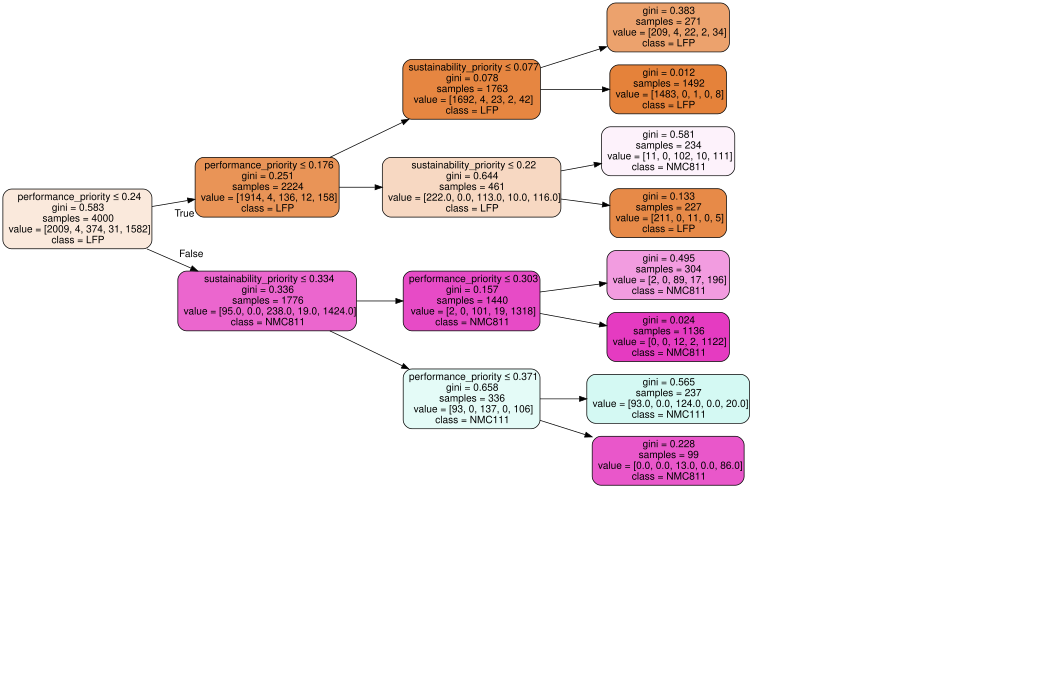

In [26]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dt,
    out_file=None,
    feature_names=X.columns,
    class_names=dt.classes_,
    filled=True,
    rounded=True,
    special_characters=True
)

# Add graph attributes
dot_data = 'digraph Tree {\nsize="15,15";\ndpi="52";\nrankdir=LR;\n' + dot_data.split('{',1)[1]

graph = graphviz.Source(dot_data)

graph

| Chemistry | Sustainability                         | Performance | Cost   | Safety |
| --------- | -------------------------------------- | ----------- | ------ | ------ |
| LFP       | High                                   | Medium      | High   | High   |
| NMC111    | Medium                                 | Medium-High | Medium | Medium |
| NMC811    | Low                                    | Very High   | Medium | Low    |
| NMC532    | Worse than NMC111 in almost everything |             |        |        |
| NMC622    | Worse than NMC811 in almost everything |             |        |        |
| NCA       | Worse than NMC811                      |             |        |        |
| LCO       | Worse than LFP and NMC111              |             |        |        |
| LMO       | Worse than LFP                         |             |        |        |
| LTO       | Too expensive and low performance      |             |        |        |


In [27]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=len(y.unique()),
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb.fit(X_train, y_train_enc)

y_pred = xgb.predict(X_test)

y_pred = le.inverse_transform(y_pred)

In [29]:
from sklearn.metrics import accuracy_score

print("XGBoost Accuracy =", accuracy_score(y_test, y_pred))

XGBoost Accuracy = 0.972


In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[491   0   7   0   1]
 [  2   0   0   0   0]
 [  3   0  73   0   4]
 [  0   0   3   0   2]
 [  3   0   2   1 408]]


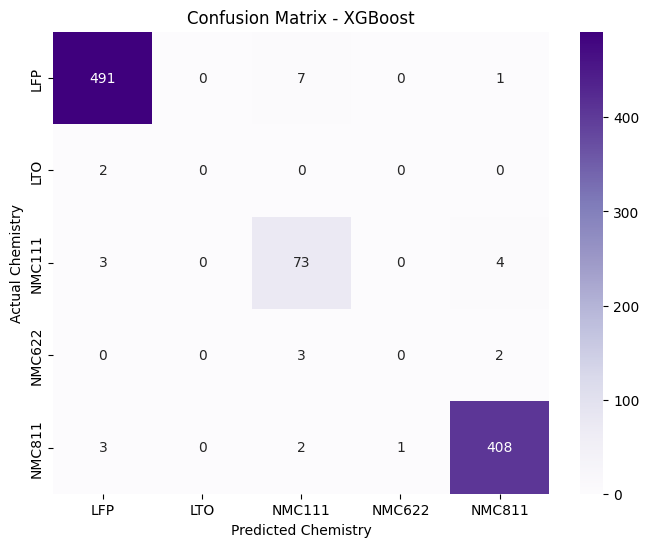

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

classes = ['LFP','LTO','NMC111','NMC622','NMC811']

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel('Predicted Chemistry')
plt.ylabel('Actual Chemistry')
plt.title('Confusion Matrix - XGBoost')

plt.show()

In [46]:
print("Enter the % of priority for the following category out of 100% overall:\n")
sust = float(input("Enter Sustainability Priority (%): "))
perf = float(input("Enter Performance Priority (%): "))
cost = float(input("Enter Cost Priority (%): "))
safe = float(input("Enter Safety Priority (%): "))
total = sust + perf + cost + safe

sust = sust/total
perf = perf/total
cost = cost/total
safe = safe/total
user_input = [[
    sust,
    perf,
    cost,
    safe
]]
pred = xgb.predict(user_input)
pred = le.inverse_transform(pred)

chemistry = pred[0]
print("Recommended Battery Chemistry :", chemistry)
subset = df[df['Chemistry'] == chemistry]

best_case = subset.loc[
    subset['sustainability_score'].idxmax()
]

print("Sustainability Score :",
      round(best_case['sustainability_score'],3))

print("Performance Score :",
      round(best_case['performance_score'],3))

print("Cost Score :",
      round(best_case['cost_score'],3))

print("Safety Score :",
      round(best_case['safety_score'],1))

Enter the % of priority for the following category out of 100% overall:

Enter Sustainability Priority (%): 20
Enter Performance Priority (%): 80
Enter Cost Priority (%): 10
Enter Safety Priority (%): 10
Recommended Battery Chemistry : NMC811
Sustainability Score : 0.625
Performance Score : 0.938
Cost Score : 0.947
Safety Score : 0.8


Although ten lithium-ion chemistries were considered, multi-criteria optimization revealed that only LFP, NMC111, and NMC811 remained Pareto-optimal under varying user priorities. The remaining chemistries were dominated and therefore rarely or never selected.
